# 🎙️ Speech Emotion Recognition

## Task 2 — Model Evaluation

This notebook evaluates the trained CNN model using the
unseen test dataset.

### Objectives

- Load the trained CNN model
- Load test features and labels
- Calculate test loss and accuracy
- Generate classification report
- Calculate precision, recall and F1-score
- Generate confusion matrix
- Visualize per-class performance
- Analyze model predictions
- Save evaluation results

## 1. Import Required Libraries

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("✓ Libraries imported successfully")
print("PyTorch version:", torch.__version__)

✓ Libraries imported successfully
PyTorch version: 2.13.0+cpu


## 2. Configure Computing Device

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Selected device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )
else:
    print("Using CPU")

Selected device: cpu
Using CPU


## 3. Load Test Dataset

The test data generated during model training is loaded from:

- `outputs/test_targets.npy`
- `outputs/test_predictions.npy`

The original MFCC features are also loaded so that
the model can independently generate predictions.

In [5]:
FEATURE_FILE = "../outputs/mfcc_features.npy"
LABEL_FILE = "../outputs/mfcc_labels.npy"

TEST_TARGETS_FILE = "../outputs/test_targets.npy"

MODEL_FILE = "../models/emotion_model.pth"
LABEL_MAP_FILE = "../models/emotion_labels.json"

required_files = [
    FEATURE_FILE,
    LABEL_FILE,
    TEST_TARGETS_FILE,
    MODEL_FILE,
    LABEL_MAP_FILE
]

for file_path in required_files:

    if not os.path.exists(file_path):

        raise FileNotFoundError(
            f"Required file not found:\n{file_path}"
        )

print("✓ All required files found")

✓ All required files found


In [ ]:
with open(
    LABEL_MAP_FILE,
    "r",
    encoding="utf-8"
) as file:

    label_mapping = json.load(file)


class_names = [
    label_mapping[str(i)]
    for i in range(len(label_mapping))
]

num_classes = len(class_names)

print("Emotion Classes")
print("================")

for index, emotion in enumerate(class_names):

    print(
        f"{index} → {emotion}"
    )

Emotion Classes
0 → angry
1 → calm
2 → disgust
3 → fearful
4 → happy
5 → neutral
6 → sad
7 → surprised


In [8]:
X = np.load(
    FEATURE_FILE
)

y = np.load(
    LABEL_FILE,
    allow_pickle=True
)

test_targets_saved = np.load(
    TEST_TARGETS_FILE
)

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

print(
    "Saved test target shape:",
    test_targets_saved.shape
)

Feature shape: (1440, 40, 94)
Label shape: (1440,)
Saved test target shape: (216,)


## 4. Recreate Test Dataset

The same random seed and stratified split used during
training are used to reproduce the test dataset.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

# Normalize exactly as in training
X = X.astype(np.float32)

mean = X.mean()
std = X.std()

X_normalized = (
    X - mean
) / (
    std + 1e-8
)


X_train, X_temp, y_train, y_temp = train_test_split(
    X_normalized,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Test samples:", len(X_test))
print("Test shape:", X_test.shape)

Test samples: 216
Test shape: (216, 40, 94)


In [11]:
X_test = np.expand_dims(
    X_test,
    axis=1
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("✓ Test DataLoader created")
print(
    "Input shape:",
    X_test_tensor.shape
)

✓ Test DataLoader created
Input shape: torch.Size([216, 1, 40, 94])


## 5. Recreate CNN Architecture

The same CNN architecture used during training
is recreated before loading the saved weights.

In [12]:
class EmotionCNN(nn.Module):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.15),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.20),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout(0.30)
        )

        self.pool = nn.AdaptiveAvgPool2d(
            (4, 4)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256 * 4 * 4,
                128
            ),

            nn.ReLU(),

            nn.BatchNorm1d(128),

            nn.Dropout(0.40),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = self.classifier(x)

        return x

In [13]:
model = EmotionCNN(
    num_classes=num_classes
).to(device)

model.load_state_dict(
    torch.load(
        MODEL_FILE,
        map_location=device
    )
)

model.eval()

print("✓ Trained model loaded successfully")
print(
    "Model file:",
    MODEL_FILE
)

✓ Trained model loaded successfully
Model file: ../models/emotion_model.pth


## 6. Generate Test Predictions

The trained CNN generates predictions for every
sample in the unseen test dataset.

In [14]:
all_predictions = []
all_targets = []
all_probabilities = []

with torch.no_grad():

    for batch_x, batch_y in test_loader:

        batch_x = batch_x.to(device)

        outputs = model(
            batch_x
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_targets.extend(
            batch_y.numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )


y_true = np.array(
    all_targets
)

y_pred = np.array(
    all_predictions
)

y_prob = np.array(
    all_probabilities
)

print("✓ Predictions generated")

print(
    "Prediction shape:",
    y_pred.shape
)

print(
    "Probability shape:",
    y_prob.shape
)

✓ Predictions generated
Prediction shape: (216,)
Probability shape: (216, 8)


## 7. Overall Model Accuracy

In [15]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print("=" * 50)
print("MODEL ACCURACY")
print("=" * 50)

print(
    f"Test Accuracy: {accuracy * 100:.2f}%"
)

MODEL ACCURACY
Test Accuracy: 58.80%


## 8. Precision, Recall and F1-Score

These metrics provide a more detailed evaluation
of the model for each emotion.

In [16]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print(
    f"Accuracy : {accuracy * 100:.2f}%"
)

print(
    f"Precision: {precision * 100:.2f}%"
)

print(
    f"Recall   : {recall * 100:.2f}%"
)

print(
    f"F1-Score : {f1 * 100:.2f}%"
)

Accuracy : 58.80%
Precision: 61.51%
Recall   : 58.80%
F1-Score : 58.05%


## 9. Classification Report

In [17]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

       angry     0.7000    0.7500    0.7241        28
        calm     0.7200    0.6207    0.6667        29
     disgust     0.5227    0.7931    0.6301        29
     fearful     0.4884    0.7241    0.5833        29
       happy     0.5714    0.4138    0.4800        29
     neutral     0.4500    0.6429    0.5294        14
         sad     0.5625    0.3103    0.4000        29
   surprised     0.8235    0.4828    0.6087        29

    accuracy                         0.5880       216
   macro avg     0.6048    0.5922    0.5778       216
weighted avg     0.6151    0.5880    0.5805       216



## 10. Confusion Matrix

The confusion matrix shows how many samples from each
actual emotion were classified into each predicted emotion.

In [18]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[21  0  3  2  1  1  0  0]
 [ 0 18  2  0  0  7  2  0]
 [ 2  0 23  1  1  1  0  1]
 [ 2  0  1 21  2  0  3  0]
 [ 3  1  3  9 12  1  0  0]
 [ 0  1  1  1  1  9  1  0]
 [ 0  5  6  6  0  1  9  2]
 [ 2  0  5  3  4  0  1 14]]


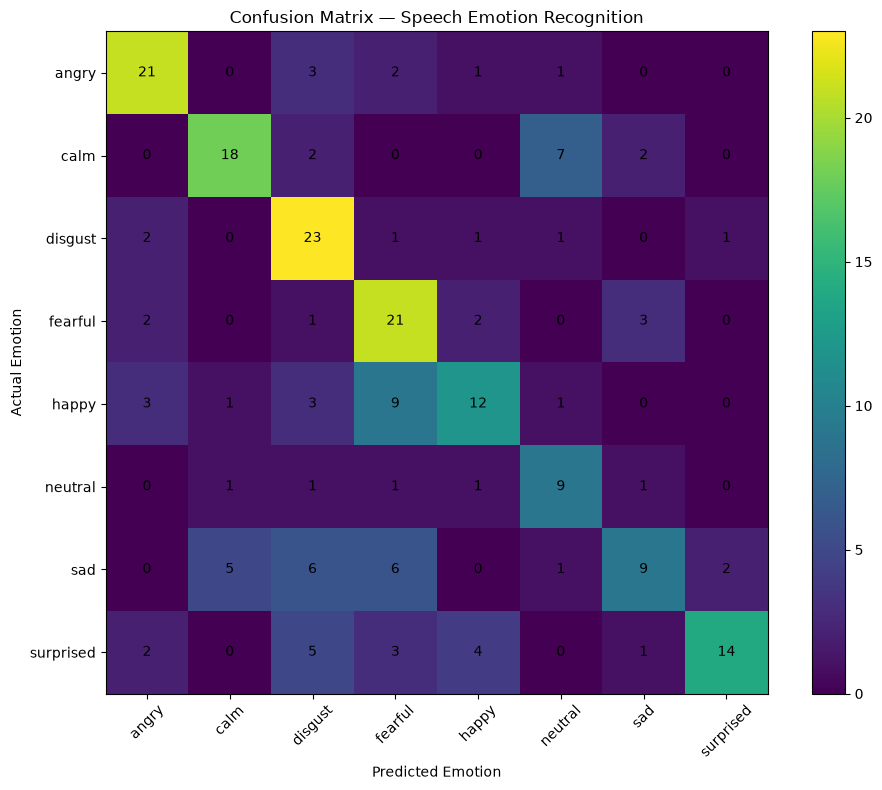

In [20]:
plt.figure(figsize=(10, 8))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Confusion Matrix — Speech Emotion Recognition"
)

plt.colorbar()

plt.xticks(
    range(num_classes),
    class_names,
    rotation=45
)

plt.yticks(
    range(num_classes),
    class_names
)

plt.xlabel(
    "Predicted Emotion"
)

plt.ylabel(
    "Actual Emotion"
)

for i in range(num_classes):

    for j in range(num_classes):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()

## 11. Per-Class Performance

In [21]:
precision_per_class = precision_score(
    y_true,
    y_pred,
    average=None,
    zero_division=0
)

recall_per_class = recall_score(
    y_true,
    y_pred,
    average=None,
    zero_division=0
)

f1_per_class = f1_score(
    y_true,
    y_pred,
    average=None,
    zero_division=0
)

metrics_df = pd.DataFrame({

    "Emotion": class_names,

    "Precision": precision_per_class,

    "Recall": recall_per_class,

    "F1-Score": f1_per_class
})

metrics_df

,Emotion,Precision,Recall,F1-Score
0,angry,0.700000,0.750000,0.724138
1,calm,0.720000,0.620690,0.666667
2,disgust,0.522727,0.793103,0.630137
3,fearful,0.488372,0.724138,0.583333
4,happy,0.571429,0.413793,0.480000
5,neutral,0.450000,0.642857,0.529412
6,sad,0.562500,0.310345,0.400000
7,surprised,0.823529,0.482759,0.608696


## 12. F1-Score by Emotion

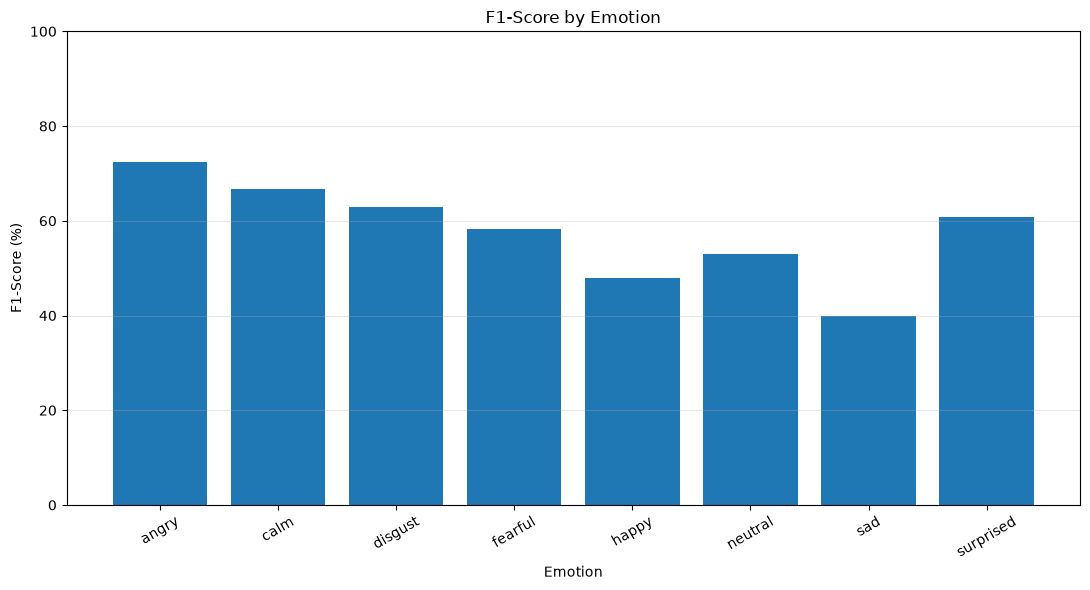

In [22]:
plt.figure(figsize=(11, 6))

plt.bar(
    metrics_df["Emotion"],
    metrics_df["F1-Score"] * 100
)

plt.title(
    "F1-Score by Emotion"
)

plt.xlabel(
    "Emotion"
)

plt.ylabel(
    "F1-Score (%)"
)

plt.xticks(
    rotation=30
)

plt.ylim(
    0,
    100
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

## 13. Precision vs Recall by Emotion

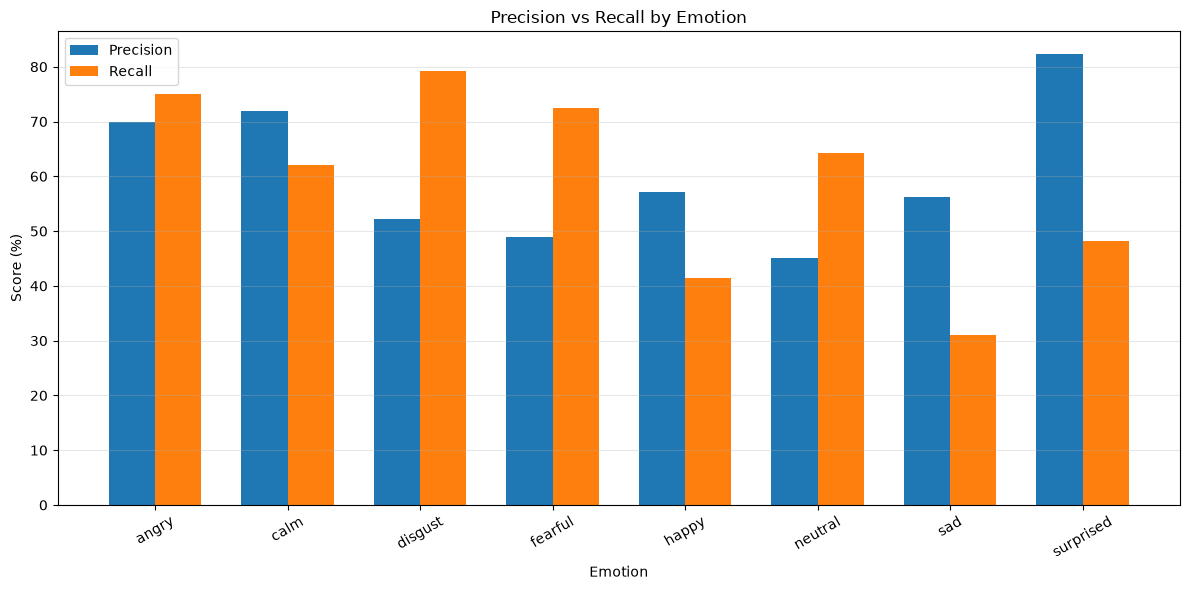

In [23]:
x = np.arange(
    len(class_names)
)

width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    metrics_df["Precision"] * 100,
    width,
    label="Precision"
)

plt.bar(
    x + width / 2,
    metrics_df["Recall"] * 100,
    width,
    label="Recall"
)

plt.xticks(
    x,
    class_names,
    rotation=30
)

plt.ylabel(
    "Score (%)"
)

plt.xlabel(
    "Emotion"
)

plt.title(
    "Precision vs Recall by Emotion"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

## 14. Prediction Confidence

The maximum softmax probability is used as the model's
confidence for each prediction.

In [24]:
confidence = np.max(
    y_prob,
    axis=1
)

print(
    f"Average Confidence: "
    f"{confidence.mean() * 100:.2f}%"
)

print(
    f"Minimum Confidence: "
    f"{confidence.min() * 100:.2f}%"
)

print(
    f"Maximum Confidence: "
    f"{confidence.max() * 100:.2f}%"
)

Average Confidence: 71.04%
Minimum Confidence: 23.86%
Maximum Confidence: 99.96%


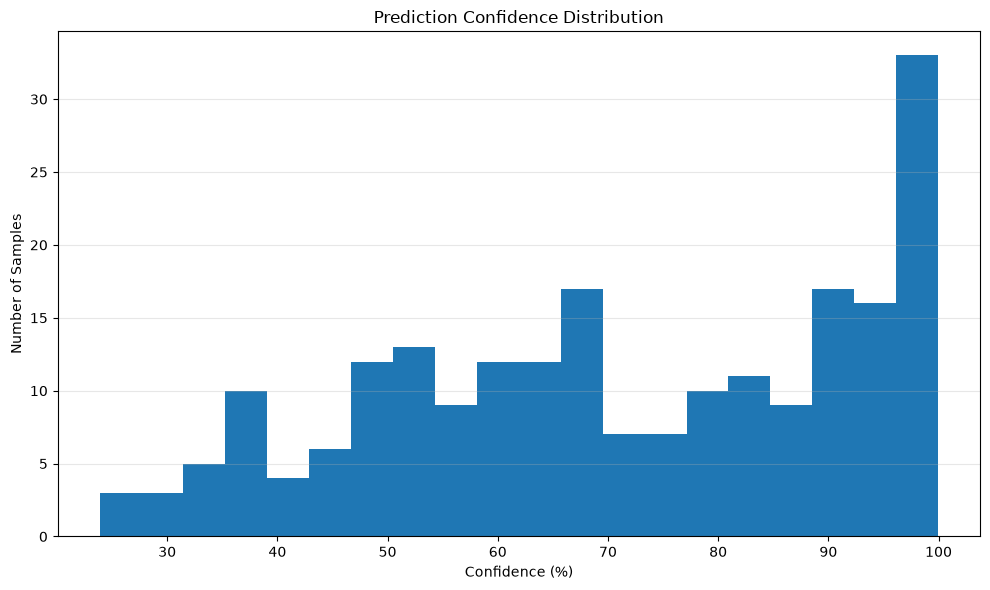

In [25]:
plt.figure(figsize=(10, 6))

plt.hist(
    confidence * 100,
    bins=20
)

plt.title(
    "Prediction Confidence Distribution"
)

plt.xlabel(
    "Confidence (%)"
)

plt.ylabel(
    "Number of Samples"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

## 15. Correct vs Incorrect Predictions

In [26]:
correct = np.sum(
    y_true == y_pred
)

incorrect = np.sum(
    y_true != y_pred
)

prediction_counts = [
    correct,
    incorrect
]

labels = [
    "Correct",
    "Incorrect"
]

print(
    f"Correct Predictions   : {correct}"
)

print(
    f"Incorrect Predictions : {incorrect}"
)

print(
    f"Total Test Samples    : {len(y_true)}"
)

Correct Predictions   : 127
Incorrect Predictions : 89
Total Test Samples    : 216


Correct Predictions   : 127
Incorrect Predictions : 89
Total Test Samples    : 216


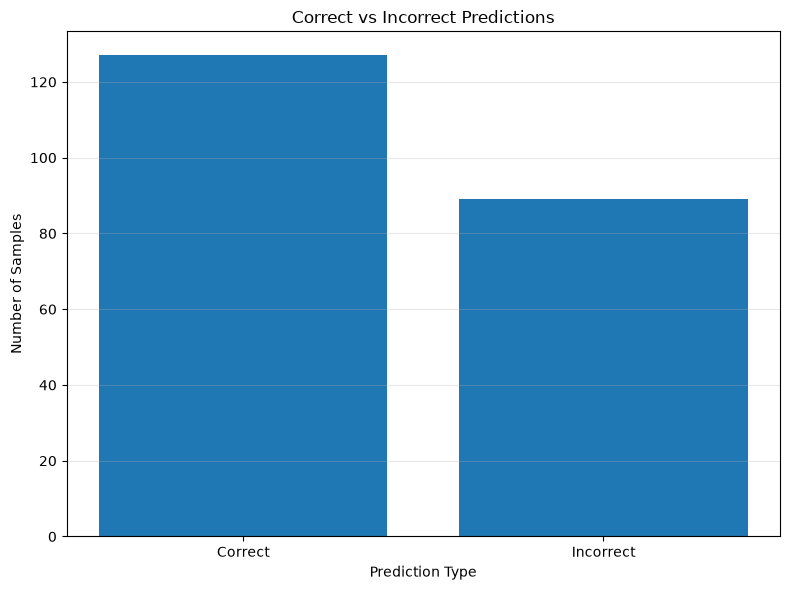

In [28]:
plt.figure(figsize=(8, 6))

plt.bar(
    labels,
    prediction_counts
)

plt.title(
    "Correct vs Incorrect Predictions"
)

plt.xlabel(
    "Prediction Type"
)

plt.ylabel(
    "Number of Samples"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

## 16. Misclassified Samples

The following table shows examples where the model
predicted the wrong emotion.

In [29]:
misclassified_indices = np.where(
    y_true != y_pred
)[0]

misclassified_df = pd.DataFrame({

    "Sample_Index":
        misclassified_indices,

    "Actual":
        [
            class_names[y_true[i]]
            for i in misclassified_indices
        ],

    "Predicted":
        [
            class_names[y_pred[i]]
            for i in misclassified_indices
        ],

    "Confidence":
        [
            confidence[i]
            for i in misclassified_indices
        ]
})

misclassified_df.head(20)

,Sample_Index,Actual,Predicted,Confidence
0,2,neutral,fearful,0.680993
1,3,sad,fearful,0.686772
2,5,happy,angry,0.239609
3,6,fearful,happy,0.595113
4,8,fearful,sad,0.530022
5,10,happy,angry,0.511055
6,11,calm,disgust,0.483746
7,13,calm,neutral,0.784177
8,17,happy,angry,0.660827
9,18,surprised,angry,0.362642


## 17. Save Evaluation Results

In [30]:
os.makedirs(
    "../outputs",
    exist_ok=True
)

evaluation_summary = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Average Confidence"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        confidence.mean()
    ]
})

evaluation_summary.to_csv(
    "../outputs/evaluation_summary.csv",
    index=False
)

metrics_df.to_csv(
    "../outputs/per_class_metrics.csv",
    index=False
)

misclassified_df.to_csv(
    "../outputs/misclassified_samples.csv",
    index=False
)

np.save(
    "../outputs/confusion_matrix.npy",
    cm
)

np.save(
    "../outputs/test_probabilities.npy",
    y_prob
)

print("✓ Evaluation results saved successfully")

✓ Evaluation results saved successfully


# Conclusion

The trained CNN-based Speech Emotion Recognition model was
successfully evaluated using the unseen test dataset.

The evaluation included accuracy, precision, recall, F1-score,
classification report, confusion matrix, prediction confidence,
and per-emotion performance analysis.

The results provide a clear understanding of the model's
classification performance and help identify emotions that are
predicted accurately as well as emotions that are more difficult
for the model to distinguish.

Overall, this evaluation confirms that the trained model is ready
for the final prediction and real-time demonstration stage.

